# Isolation Forest (Unsupervised)

In [14]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import StandardScaler
from sklearn.ensemble import IsolationForest
from sklearn.metrics import classification_report, confusion_matrix, roc_curve, roc_auc_score, precision_recall_curve, auc

## Load and Prepare Data

In [15]:
# Load data
df = pd.read_csv('feature_engineered.csv')
print(f"Dataset shape: {df.shape}")
df.head()

Dataset shape: (101322, 35)


,DateTime,Time,Date,Sender_account,Receiver_account,Amount,Payment_currency,Received_currency,Sender_bank_location,Receiver_bank_location,...,Receiver_Tx_Count,Receiver_Mean_Amount,Hour_Tx_Volume,Time_Since_Last_Tx,unique_receivers_per_sender,unique_senders_per_receiver,sender_country_risk,receiver_country_risk,global_transactions_last_1_hour,sender_transactions_last_1_hour
0,2022-10-07 10:35:20,10:35:20,2022-10-07,1491989064,8401255335,6019.64,10,1,16,15,...,12,6021.031667,524766.5557,0.0,3,1,0.002677,0.002237,1.0,1.0
1,2022-10-07 10:35:37,10:35:37,2022-10-07,7017008854,3714297114,1971.15,10,2,16,12,...,3,1882.790000,524766.5557,0.0,2,1,0.002677,0.001891,2.0,1.0
2,2022-10-07 10:35:38,10:35:38,2022-10-07,2047410771,6646502650,8110.72,10,2,16,2,...,167,10644.205928,524766.5557,0.0,1,18,0.002677,0.002751,3.0,1.0
3,2022-10-07 10:35:43,10:35:43,2022-10-07,4473647189,7892884492,11957.87,10,11,16,17,...,108,11712.785463,524766.5557,0.0,1,13,0.002677,0.000997,4.0,1.0
4,2022-10-07 10:36:05,10:36:05,2022-10-07,1203252958,8500212178,2438.30,10,4,16,7,...,3,2120.536667,524766.5557,0.0,1,1,0.002677,0.002006,5.0,1.0


In [16]:
# Check class distribution
print("\nClass distribution:")
print(df['Is_laundering'].value_counts())
print(f"\nFraud percentage: {df['Is_laundering'].sum() / len(df) * 100:.2f}%")


Class distribution:
Is_laundering
0    101093
1       229
Name: count, dtype: int64

Fraud percentage: 0.23%


In [17]:
# Drop unnecessary columns
df = df.drop(['DateTime', 'Time', 'Date', 'Sender_account', 'Receiver_account'], axis=1)

# Separate features and target
X = df.drop("Is_laundering", axis=1).values
y = df["Is_laundering"].values

print(f"Features shape: {X.shape}")
print(f"Target shape: {y.shape}")

Features shape: (101322, 29)
Target shape: (101322,)


## Feature Scaling

In [18]:
# Scale features
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)
print("Features scaled successfully")

Features scaled successfully


In [19]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X_scaled, y, test_size=0.2, random_state=42, stratify=y
)

print(f"Training set size: {X_train.shape[0]}")
print(f"Testing set size: {X_test.shape[0]}")
print(f"\nTraining set fraud percentage: {y_train.sum() / len(y_train) * 100:.2f}%")
print(f"Testing set fraud percentage: {y_test.sum() / len(y_test) * 100:.2f}%")


Training set size: 81057
Testing set size: 20265

Training set fraud percentage: 0.23%
Testing set fraud percentage: 0.23%


## Train Isolation Forest Model

In [20]:
# Initialize and train Isolation Forest
# contamination parameter is set to the approximate fraud rate
contamination_rate = y.sum() / len(y)
print(f"Setting contamination rate to: {contamination_rate:.4f}")

iso_forest = IsolationForest(
    n_estimators=100,
    contamination=contamination_rate,
    random_state=42,
    n_jobs=-1
)

print("\nTraining Isolation Forest...")
iso_forest.fit(X_train)

print("Training complete!")

Setting contamination rate to: 0.0023

Training Isolation Forest...
Training complete!


## Make Predictions

In [21]:
# Get predictions (-1 for anomalies, 1 for normal)
y_pred_raw = iso_forest.predict(X_test)
y_pred = np.where(y_pred_raw == -1, 1, 0)
anomaly_scores = iso_forest.score_samples(X_test)
y_scores = -anomaly_scores


print(f"Anomalies detected: {y_pred.sum()}")
print(f"Actual frauds: {y.sum()}")
print(f"\nAnomaly score range: [{anomaly_scores.min():.4f}, {anomaly_scores.max():.4f}]")

Anomalies detected: 44
Actual frauds: 229

Anomaly score range: [-0.6522, -0.3758]


## Model Evaluation

In [22]:
# Classification Report
print("Classification Report:")
print(classification_report(y_test, y_pred))

Classification Report:
              precision    recall  f1-score   support

           0       1.00      1.00      1.00     20219
           1       0.00      0.00      0.00        46

    accuracy                           1.00     20265
   macro avg       0.50      0.50      0.50     20265
weighted avg       1.00      1.00      1.00     20265




Confusion Matrix:
[[20175    44]
 [   46     0]]


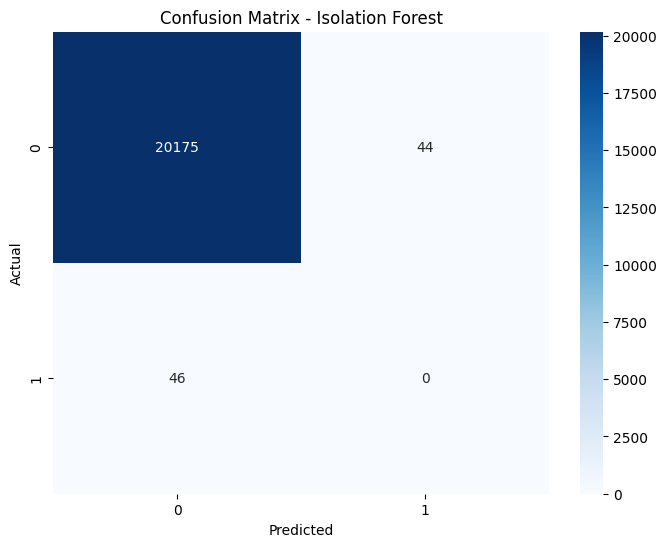

In [23]:
# Confusion Matrix
cm = confusion_matrix(y_test, y_pred)
print("\nConfusion Matrix:")
print(cm)

plt.figure(figsize=(8, 6))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues')
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Confusion Matrix - Isolation Forest")
plt.show()

## ROC Curve

ROC AUC Score: 0.5239


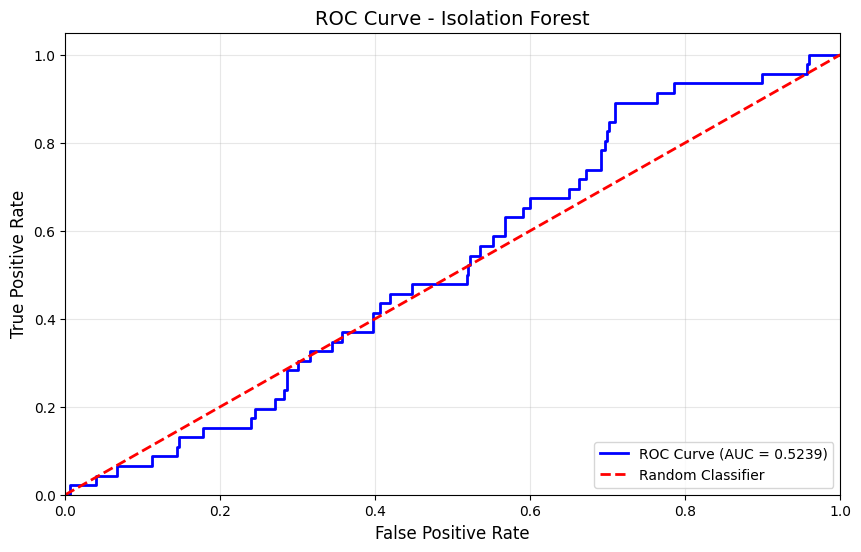

In [24]:
# Calculate ROC curve and AUC
fpr, tpr, thresholds = roc_curve(y_test, y_scores)
roc_auc = roc_auc_score(y_test, y_scores)

print(f"ROC AUC Score: {roc_auc:.4f}")

# Plot ROC curve
plt.figure(figsize=(10, 6))
plt.plot(fpr, tpr, color='blue', lw=2, label=f'ROC Curve (AUC = {roc_auc:.4f})')
plt.plot([0, 1], [0, 1], color='red', lw=2, linestyle='--', label='Random Classifier')
plt.xlim([0.0, 1.0])
plt.ylim([0.0, 1.05])
plt.xlabel('False Positive Rate', fontsize=12)
plt.ylabel('True Positive Rate', fontsize=12)
plt.title('ROC Curve - Isolation Forest', fontsize=14)
plt.legend(loc="lower right")
plt.grid(alpha=0.3)
plt.show()

## Precision-Recall Curve

Precision-Recall AUC (Average Precision): 0.0025


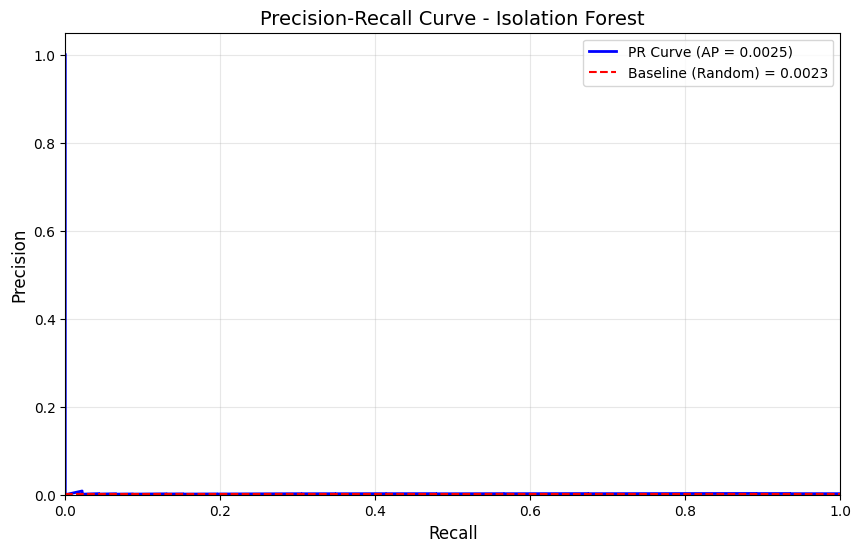

In [25]:
# Calculate Precision-Recall curve
from sklearn.metrics import average_precision_score

precision, recall, pr_thresholds = precision_recall_curve(y_test, y_scores)

# Calculate AUC using average_precision_score (correct method for PR curve)
pr_auc = average_precision_score(y_test, y_scores)

print(f"Precision-Recall AUC (Average Precision): {pr_auc:.4f}")

# Plot Precision-Recall curve
plt.figure(figsize=(10, 6))
plt.plot(recall, precision, color='blue', lw=2, label=f'PR Curve (AP = {pr_auc:.4f})')
plt.axhline(y=y.sum()/len(y), color='red', linestyle='--', label=f'Baseline (Random) = {y.sum()/len(y):.4f}')
plt.xlim([0.0, 1.0])
plt.ylim([0.0, 1.05])
plt.xlabel('Recall', fontsize=12)
plt.ylabel('Precision', fontsize=12)
plt.title('Precision-Recall Curve - Isolation Forest', fontsize=14)
plt.legend(loc="best")
plt.grid(alpha=0.3)
plt.show()

## Anomaly Score Distribution

C:\Users\HP\AppData\Local\Temp\ipykernel_17648\3295853921.py:14: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  plt.boxplot([anomaly_scores[y_test == 0], anomaly_scores[y_test == 1]], labels=['Normal', 'Fraud'])


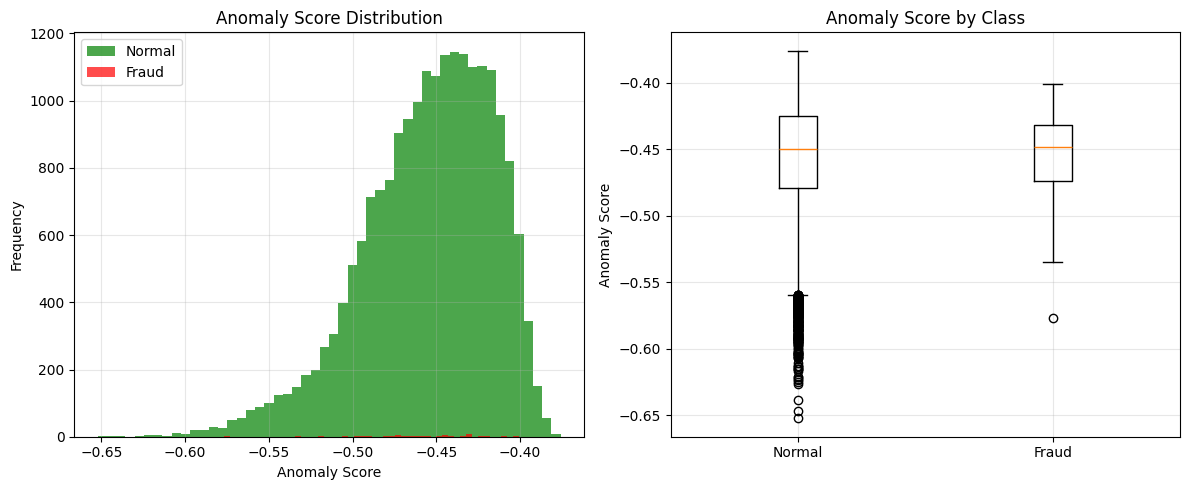

In [27]:
# Plot anomaly score distribution
plt.figure(figsize=(12, 5))

plt.subplot(1, 2, 1)
plt.hist(anomaly_scores[y_test == 0], bins=50, alpha=0.7, label='Normal', color='green')
plt.hist(anomaly_scores[y_test == 1], bins=50, alpha=0.7, label='Fraud', color='red')
plt.xlabel('Anomaly Score')
plt.ylabel('Frequency')
plt.title('Anomaly Score Distribution')
plt.legend()
plt.grid(alpha=0.3)

plt.subplot(1, 2, 2)
plt.boxplot([anomaly_scores[y_test == 0], anomaly_scores[y_test == 1]], labels=['Normal', 'Fraud'])
plt.ylabel('Anomaly Score')
plt.title('Anomaly Score by Class')
plt.grid(alpha=0.3)

plt.tight_layout()
plt.show()

## Summary Statistics

In [ ]:
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score

print("=" * 50)
print("ISOLATION FOREST - PERFORMANCE SUMMARY")
print("=" * 50)
print(f"Accuracy:  {accuracy_score(y_test, y_pred):.4f}")
print(f"Precision: {precision_score(y_test, y_pred, zero_division=0):.4f}")
print(f"Recall:    {recall_score(y_test, y_pred, zero_division=0):.4f}")
print(f"F1-Score:  {f1_score(y_test, y_pred, zero_division=0):.4f}")
print(f"ROC AUC:   {roc_auc:.4f}")
print(f"PR AUC (Average Precision): {pr_auc:.4f}")
print("=" * 50)

ISOLATION FOREST - PERFORMANCE SUMMARY
Accuracy:  0.9955
Precision: 0.0087
Recall:    0.0087
F1-Score:  0.0087
ROC AUC:   0.5697
PR AUC (Average Precision): 0.0028
